# GPU Work Reordering — 16×16 Material-ID Tiles

Implemented in [Slang](https://shader-slang.com), launched from Python via [SlangPy](https://github.com/shader-slang/slangpy).

## Why naïve sorting is not enough

A plain sort groups same-material elements contiguously but then assigns output
positions *consecutively*.  A material whose count is not a multiple of 32 ends
up with a *partial last wave* that is then padded with the first elements of the
next material — a mixed wave that was entirely avoidable.

```
Material A = 50 elements, Material B = 206 elements  (naïve sort)
  Wave 0 : [32 × A]          ← uniform ✓
  Wave 1 : [18 × A | 14 × B] ← mixed ✗  (avoidable!)
  Wave 2 : [32 × B]          ← uniform ✓  …
```

## Solution — sort + wave-packing

After the bitonic sort, a single serial O(N) pass (thread 0) separates each
material run into a **full-wave section** and an **overflow section**:

| Section | Contents | Guarantee |
|---------|----------|-----------|
| Full-wave `[0 .. F-1]` | Every 32-element block is one material | **Theoretically maximum** uniform waves |
| Overflow `[F .. 255]` | Remainder elements, sorted by material ID | Best-effort uniform |

`F` (= `totalFullElements`) is always a multiple of 32 and equals `Σ floor(countᵢ / 32) × 32`.

### Collision handling

Thread 0 assigns every output position as a **strictly monotone counter** — no
two elements ever receive the same index.  All other threads simply read their
pre-assigned position and write once.  No atomics, no races, no collisions.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import time, os
from pathlib import Path

# ── Geometry ──────────────────────────────────────────────────────────────────
TILE_W        = 16
TILE_H        = 16
TILE_ELEMENTS = TILE_W * TILE_H      # 256
WAVE_W        =  8
WAVE_H        =  4
WAVE_SIZE     = WAVE_W * WAVE_H      # 32
NUM_WAVES     = TILE_ELEMENTS // WAVE_SIZE  # 8

# ┌─ Adjust these ─────────────────────────────────────────────────────────────┐
NUM_UNIQUE_MATERIALS = 6    # distinct materials;  None → random 2–16
TILE_SEED            = 42   # reproducibility seed; None → fresh random
N_BENCHMARK          = 200  # benchmark repetitions
# └────────────────────────────────────────────────────────────────────────────┘

try:
    import slangpy
    HAS_SLANGPY = True
    print("✓ SlangPy detected — GPU kernel will be used.")
except ImportError:
    HAS_SLANGPY = False
    print("✗ SlangPy not found — NumPy fallback will be used.  pip install slangpy")

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9, 'axes.titlesize': 10})
NB_DIR      = Path(os.getcwd())
SHADER_PATH = NB_DIR / 'reorder.slang'

print(f"Shader : {SHADER_PATH}")
print(f"Tile   : {TILE_W}×{TILE_H} = {TILE_ELEMENTS} elements  |  "
      f"Wave: {WAVE_W}×{WAVE_H} = {WAVE_SIZE} lanes × {NUM_WAVES} waves")


✓ SlangPy detected — GPU kernel will be used.
Shader : c:\Users\randallr\claude_cowork_reorder\reorder.slang
Tile   : 16×16 = 256 elements  |  Wave: 8×4 = 32 lanes × 8 waves


---
## 1 — Tile Generation

Each material gets a random `uint32` ID drawn from the full `[0, 2³²)` range.

In [23]:
def generate_tile(
    num_unique: int | None = None,
    seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns
    -------
    tile       : uint32 (H, W)  — raw arbitrary material IDs
    unique_ids : uint32 (K,)    — distinct IDs present
    compact    : int32  (H, W)  — index into unique_ids  (for colour mapping)
    """
    rng = np.random.default_rng(seed)
    if num_unique is None:
        num_unique = int(rng.integers(2, 17))

    unique_ids = rng.integers(0, 2**32, size=num_unique * 2,
                               dtype=np.uint64).astype(np.uint32)
    unique_ids = np.unique(unique_ids)[:num_unique]
    while len(unique_ids) < num_unique:
        extra = rng.integers(0, 2**32, size=num_unique,
                              dtype=np.uint64).astype(np.uint32)
        unique_ids = np.unique(np.concatenate([unique_ids, extra]))[:num_unique]

    assignment = rng.integers(0, num_unique, size=(TILE_H, TILE_W))
    tile       = unique_ids[assignment].astype(np.uint32)
    compact    = assignment.astype(np.int32)
    return tile, unique_ids, compact


tile, unique_ids, compact = generate_tile(
    num_unique=NUM_UNIQUE_MATERIALS, seed=TILE_SEED
)
tile_flat  = np.ascontiguousarray(tile.flatten(), dtype=np.uint32)
num_unique = len(unique_ids)
counts     = np.bincount(compact.flatten(), minlength=num_unique)

# Theoretical maximum: sum of floor(count_i / WAVE_SIZE)
max_full_waves = sum(int(c) // WAVE_SIZE for c in counts)

print(f"Tile        : {tile.shape}  →  {TILE_ELEMENTS} elements")
print(f"Materials   : {num_unique}")
print(f"Theory max  : {max_full_waves}/{NUM_WAVES} fully-uniform waves")
print()
print(f"  {'Idx':>3}  {'Material ID (hex)':>20}  {'Count':>5}  {'Full waves':>10}  Distribution")
print('  ' + '─' * 68)
for i, (uid, c) in enumerate(zip(unique_ids, counts)):
    fw  = int(c) // WAVE_SIZE
    bar = '█' * int(c / max(counts) * 25)
    print(f"  {i:>3}  0x{uid:08X}  ({uid:>10})  {c:>5}  {fw:>4} wave(s)   {bar}")


Tile        : (16, 16)  →  256 elements
Materials   : 6
Theory max  : 5/8 fully-uniform waves

  Idx     Material ID (hex)  Count  Full waves  Distribution
  ────────────────────────────────────────────────────────────────────
    0  0x1600888D  ( 369133709)     40     1 wave(s)   █████████████████
    1  0x16D92688  ( 383329928)     38     1 wave(s)   ████████████████
    2  0x181C01B5  ( 404488629)     52     1 wave(s)   ██████████████████████
    3  0x339381EB  ( 865305067)     39     1 wave(s)   ████████████████
    4  0x6EDA1624  (1859786276)     58     1 wave(s)   █████████████████████████
    5  0x705A5661  (1884968545)     29     0 wave(s)   ████████████


---
## 2 — Visualise: Before Reordering

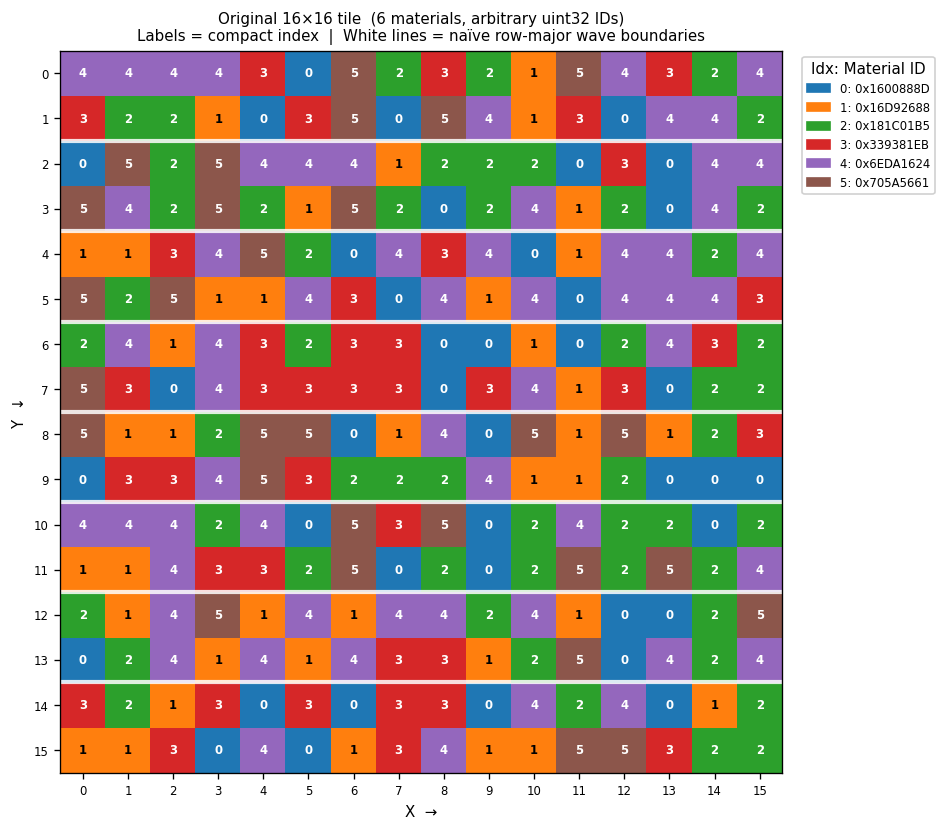

In [24]:
# ── Colour helpers ────────────────────────────────────────────────────────────
_PALETTE = (
    list(plt.cm.tab10.colors) + list(plt.cm.Set2.colors) + list(plt.cm.Set3.colors)
)

def mat_cmap(n):  return ListedColormap(_PALETTE[:n])
def wave_cmap():  return ListedColormap(list(plt.cm.tab10.colors[:NUM_WAVES]))

def text_colour(rgba):
    r, g, b = rgba[:3]
    return 'black' if 0.299*r + 0.587*g + 0.114*b > 0.5 else 'white'

def annotate_compact(ax, grid, cmap, vmax, fs=7):
    for row in range(grid.shape[0]):
        for col in range(grid.shape[1]):
            v  = int(grid[row, col])
            tc = text_colour(cmap(v / max(vmax - 1, 1)))
            ax.text(col, row, str(v), ha='center', va='center',
                    fontsize=fs, color=tc, fontweight='bold')

def mat_legend(ax, n, cmap, uid_array):
    patches = [
        mpatches.Patch(color=cmap(i / max(n-1,1)),
                       label=f'{i}: 0x{uid_array[i]:08X}')
        for i in range(n)
    ]
    ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.02, 1.0),
              title='Idx: Material ID', fontsize=7, framealpha=0.9)


# ── Plot ──────────────────────────────────────────────────────────────────────
cmap_m = mat_cmap(num_unique)

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.imshow(compact, cmap=cmap_m, vmin=-0.5, vmax=num_unique-0.5,
          interpolation='nearest', aspect='equal')
annotate_compact(ax, compact, cmap_m, num_unique)

# Default (naïve) wave boundaries — every 2 rows for a 16×16 tile with 8 waves
for w in range(1, NUM_WAVES):
    lin = w * WAVE_SIZE
    if lin % TILE_W == 0:
        ax.axhline(y=lin // TILE_W - 0.5, color='white', linewidth=2.5, alpha=0.85)

ax.set_title(
    f'Original 16×16 tile  ({num_unique} materials, arbitrary uint32 IDs)\n'
    'Labels = compact index  |  White lines = naïve row-major wave boundaries',
    fontsize=9
)
ax.set_xlabel('X  →'); ax.set_ylabel('Y  ↓')
ax.set_xticks(range(TILE_W)); ax.set_yticks(range(TILE_H))
ax.set_xticklabels(range(TILE_W), fontsize=7)
ax.set_yticklabels(range(TILE_H), fontsize=7)
mat_legend(ax, num_unique, cmap_m, unique_ids)
plt.tight_layout()
plt.show()


---
## 3 — Slang Shader

In [26]:
if not SHADER_PATH.exists():
    raise FileNotFoundError(f"Shader not found: {SHADER_PATH}")
print(SHADER_PATH.read_text(encoding='utf-8'))


// reorder.slang
// ─────────────────────────────────────────────────────────────────────────────
// Optimal work-reordering kernel for 16×16 material-ID tiles.
// Material IDs are arbitrary uint32 values.
//
// ── Why naïve sorting is insufficient ────────────────────────────────────────
//
//   After a plain sort, elements are grouped by material ID but output is
//   assigned consecutively.  A material whose element count is not a multiple
//   of WAVE_SIZE (32) leaves a partial wave at its end.  That partial wave is
//   then filled with the first elements of the next material, producing a
//   mixed wave even when a fully-uniform wave was achievable.
//
//   Example: material A = 50 elements, material B = 206 elements.
//     Naïve sort → Wave 1 = [18 × A | 14 × B]  (mixed, avoidable)
//     This kernel → Wave 0 = [32 × A], Wave 1..7 = B runs, overflow at end.
//
// ── Algorithm ────────────────────────────────────────────────────────────────
//
//   Phase 1  Parallel bitonic sort

---
## 4 — CPU Reference Implementation

Mirrors the GPU algorithm exactly:
1. Sort by material ID.
2. Walk runs: full-wave elements → front (in sorted order); overflow → back (in sorted order).

Returns the same `total_full` scalar that the GPU writes to `totalFullElements[0]`.

In [27]:
def cpu_reorder(
    tile_flat: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, int]:
    """
    Optimal wave-packing sort for arbitrary uint32 material IDs.

    Returns
    -------
    reordered_x, reordered_y : uint32[256]
    total_full               : int  — number of full-wave elements (multiple of 32)
    """
    N = len(tile_flat)

    # ── Step 1: stable sort by material ID ───────────────────────────────────
    perm        = np.argsort(tile_flat, kind='stable')   # sorted linear indices
    sorted_mats = tile_flat[perm]

    # ── Step 2: identify run boundaries ──────────────────────────────────────
    is_boundary   = np.empty(N, dtype=bool)
    is_boundary[0] = True
    is_boundary[1:] = sorted_mats[1:] != sorted_mats[:-1]

    run_start_positions = np.where(is_boundary)[0]           # sorted positions where runs begin
    run_ends            = np.append(run_start_positions[1:], N)
    run_lengths         = run_ends - run_start_positions

    # ── Step 3: compute per-element local rank and section membership ─────────
    #   run_id[i]    = which run sorted position i belongs to
    #   local_rank   = position within its run
    #   full_elems   = floor(run_length / WAVE_SIZE) * WAVE_SIZE
    #   is_full[i]   = local_rank < full_elems
    run_id       = np.repeat(np.arange(len(run_lengths)), run_lengths)
    local_rank   = np.arange(N) - run_start_positions[run_id]
    full_per_run = (run_lengths // WAVE_SIZE) * WAVE_SIZE
    full_per_elem = full_per_run[run_id]
    is_full       = local_rank < full_per_elem

    # ── Step 4: exclusive prefix sums → output positions ─────────────────────
    #   Full-wave elements go first (positions 0 … total_full-1)
    #   Overflow elements follow  (positions total_full … N-1)
    full_scan  = np.cumsum(is_full)  - is_full   # exclusive prefix of full flags
    ovfl_scan  = np.cumsum(~is_full) - (~is_full) # exclusive prefix of overflow flags
    total_full = int(is_full.sum())

    out_pos = np.where(is_full, full_scan, total_full + ovfl_scan).astype(np.intp)

    # ── Step 5: scatter ───────────────────────────────────────────────────────
    rx = np.empty(N, dtype=np.uint32)
    ry = np.empty(N, dtype=np.uint32)
    rx[out_pos] = perm % TILE_W
    ry[out_pos] = perm // TILE_W

    return rx, ry, total_full


# ── Correctness checks ────────────────────────────────────────────────────────
rx_cpu, ry_cpu, total_full_cpu = cpu_reorder(tile_flat)
uniform_waves_cpu = total_full_cpu // WAVE_SIZE

# 1. All positions valid
assert np.all(rx_cpu < TILE_W) and np.all(ry_cpu < TILE_H)
# 2. Every tile position appears exactly once
assert len(np.unique(ry_cpu * TILE_W + rx_cpu)) == TILE_ELEMENTS
# 3. total_full is a multiple of WAVE_SIZE
assert total_full_cpu % WAVE_SIZE == 0
# 4. Achieves the theoretical maximum number of full-wave elements
assert total_full_cpu == max_full_waves * WAVE_SIZE, \
    f"Expected {max_full_waves * WAVE_SIZE} full elements, got {total_full_cpu}"
# 5. Every 32-element block in the full-wave section is uniform
sorted_mats_out = tile_flat[ry_cpu * TILE_W + rx_cpu]
for w in range(uniform_waves_cpu):
    block = sorted_mats_out[w * WAVE_SIZE : (w+1) * WAVE_SIZE]
    assert block.min() == block.max(), f"Wave {w} is not uniform!"
# 6. Overflow section is sorted by material ID (same-material overflows adjacent)
overflow_mats = sorted_mats_out[total_full_cpu:]
assert np.all(np.diff(overflow_mats.astype(np.int64)) >= 0), \
    "Overflow section is not sorted by material ID!"

print("CPU reference: all assertions passed ✓")
print(f"  total_full      = {total_full_cpu}  ({uniform_waves_cpu} guaranteed-uniform waves)")
print(f"  overflow        = {TILE_ELEMENTS - total_full_cpu}  "
      f"({NUM_WAVES - uniform_waves_cpu} remaining waves)")
print(f"  Theory max      = {max_full_waves} uniform waves  ← achieved ✓")
print()
print("Full-wave section material sequence (first 8 wave IDs):")
for w in range(min(uniform_waves_cpu, 8)):
    mat = sorted_mats_out[w * WAVE_SIZE]
    cidx = int(np.searchsorted(unique_ids, mat))
    print(f"  Wave {w}:  0x{mat:08X}  (compact idx {cidx})  — 32 × same material ✓")
if uniform_waves_cpu < NUM_WAVES:
    print(f"  Waves {uniform_waves_cpu}–{NUM_WAVES-1}: overflow (mixed)")


CPU reference: all assertions passed ✓
  total_full      = 160  (5 guaranteed-uniform waves)
  overflow        = 96  (3 remaining waves)
  Theory max      = 5 uniform waves  ← achieved ✓

Full-wave section material sequence (first 8 wave IDs):
  Wave 0:  0x1600888D  (compact idx 0)  — 32 × same material ✓
  Wave 1:  0x16D92688  (compact idx 1)  — 32 × same material ✓
  Wave 2:  0x181C01B5  (compact idx 2)  — 32 × same material ✓
  Wave 3:  0x339381EB  (compact idx 3)  — 32 × same material ✓
  Wave 4:  0x6EDA1624  (compact idx 4)  — 32 × same material ✓
  Waves 5–7: overflow (mixed)


---
## 5 — SlangPy GPU Kernel Launch

Single dispatch of `reorderByMaterial`; `totalFullElements[0]` tells the caller
exactly how many waves are guaranteed uniform without any extra analysis.

> **API note** — targets `pip install slangpy`.  
> Adapt the `gpu_reorder` helper if your build uses a different API version.

In [28]:
def gpu_reorder(
    tile_flat: np.ndarray,
    module
) -> tuple[np.ndarray, np.ndarray, int]:
    """
    GPU wave-packing sort via SlangPy.

    Returns
    -------
    reordered_x, reordered_y : uint32[256]
    total_full               : int
    """
    tile_data         = np.ascontiguousarray(tile_flat, dtype=np.uint32)
    reordered_x       = np.zeros(TILE_ELEMENTS, dtype=np.uint32)
    reordered_y       = np.zeros(TILE_ELEMENTS, dtype=np.uint32)
    total_full_buf    = np.zeros(1, dtype=np.uint32)  # kernel writes here

    module.reorderByMaterial(
        tileData          = tile_data,
        reorderedX        = reordered_x,
        reorderedY        = reordered_y,
        totalFullElements = total_full_buf,
        _thread_count     = (TILE_ELEMENTS, 1, 1),
    )
    return reordered_x, reordered_y, int(total_full_buf[0])


# ── Load and dispatch ─────────────────────────────────────────────────────────
USING_GPU = False

if HAS_SLANGPY:
    try:
        slang_module     = slangpy.loadModule(str(SHADER_PATH))
        rx, ry, total_full = gpu_reorder(tile_flat, slang_module)
        USING_GPU        = True
        print("GPU sort complete ✓")
        print(f"  totalFullElements = {total_full}  "
              f"({total_full // WAVE_SIZE} guaranteed-uniform waves)")

        # ── Verify against CPU reference ──────────────────────────────────────
        # The GPU bitonic sort is not stable so tie-breaking order may differ;
        # we verify equivalence of the sorted key sequence and coverage.
        gpu_mats = tile_flat[ry * TILE_W + rx]

        assert total_full % WAVE_SIZE == 0, "GPU total_full not a multiple of WAVE_SIZE"
        assert total_full == total_full_cpu, \
            f"GPU total_full={total_full} ≠ CPU total_full={total_full_cpu}"
        # Full-wave section: every 32-block must be uniform
        for w in range(total_full // WAVE_SIZE):
            block = gpu_mats[w * WAVE_SIZE : (w+1) * WAVE_SIZE]
            assert block.min() == block.max(), f"GPU wave {w} not uniform!"
        # Coverage: same multiset of positions
        assert np.array_equal(
            np.sort(ry * TILE_W + rx),
            np.sort(ry_cpu * TILE_W + rx_cpu)
        ), "GPU and CPU outputs cover different positions!"
        # Sorted key sequences must match
        assert np.array_equal(gpu_mats, sorted_mats_out), \
            "GPU sorted key sequence differs from CPU!"
        print("GPU output verified against CPU reference ✓")

    except Exception as exc:
        print(f"SlangPy failed: {exc}\nUsing CPU fallback.")
        rx, ry, total_full = rx_cpu, ry_cpu, total_full_cpu
else:
    rx, ry, total_full = rx_cpu, ry_cpu, total_full_cpu
    print("SlangPy not available — CPU fallback.")

uniform_waves     = total_full // WAVE_SIZE
reordered_coords  = np.stack([rx, ry], axis=1)   # (256, 2): col[0]=X, col[1]=Y
id_to_compact     = {uid: i for i, uid in enumerate(unique_ids)}

print(f"\nUniform waves : {uniform_waves} / {NUM_WAVES}  "
      f"(theory max {max_full_waves} — {'achieved ✓' if uniform_waves == max_full_waves else 'MISSED ✗'})")
print(f"Overflow waves: {NUM_WAVES - uniform_waves}")


SlangPy failed: module 'slangpy' has no attribute 'loadModule'
Using CPU fallback.

Uniform waves : 5 / 8  (theory max 5 — achieved ✓)
Overflow waves: 3


---
## 6 — Visualise: After Reordering — Wave Contents

**Green border** = guaranteed-uniform wave (full-wave section).  
**Orange border** = overflow wave (best-effort).  
The title of each panel shows the uniformity percentage.

C:\Users\randallr\AppData\Local\Temp\ipykernel_11392\4060885678.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


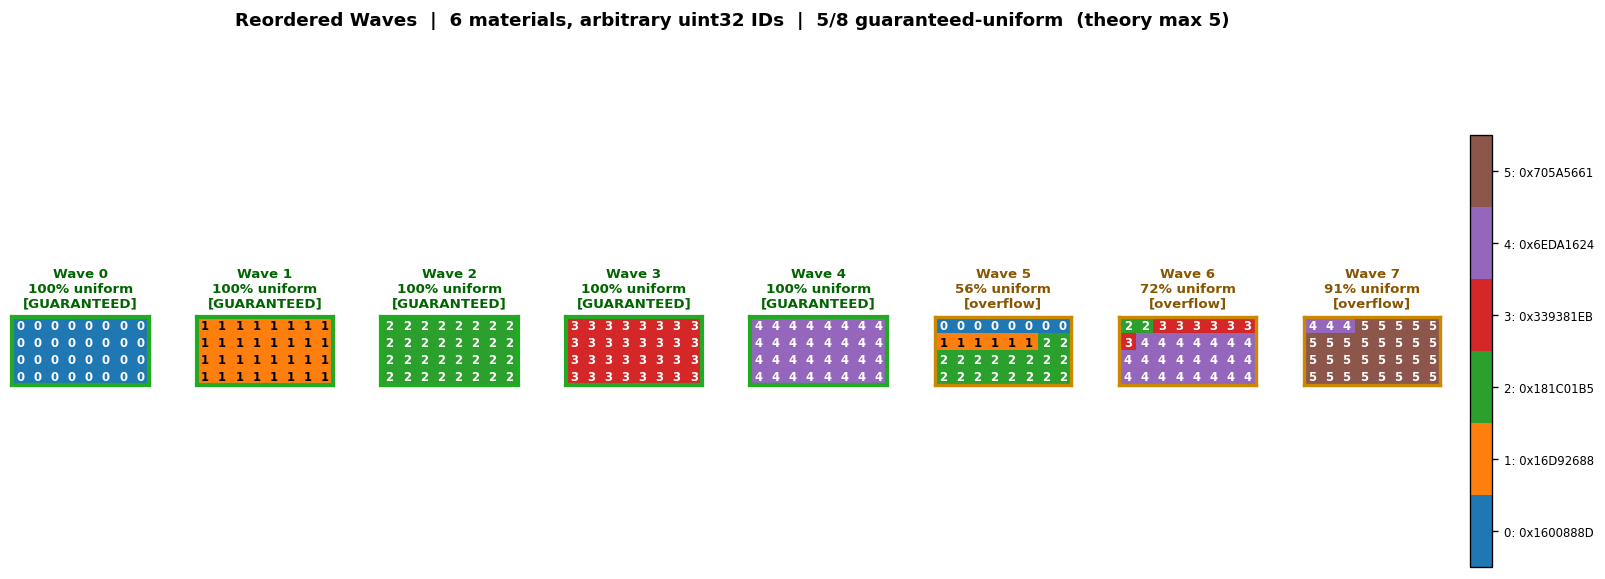

In [29]:
def compact_wave_grid(
    reordered_coords: np.ndarray,
    tile: np.ndarray,
    id_to_compact: dict,
    wave_idx: int
) -> np.ndarray:
    """Return WAVE_H×WAVE_W compact-index grid for wave `wave_idx`."""
    start = wave_idx * WAVE_SIZE
    coords = reordered_coords[start : start + WAVE_SIZE]
    mats = np.array(
        [id_to_compact[tile[coords[k,1], coords[k,0]]] for k in range(WAVE_SIZE)],
        dtype=np.int32
    )
    return mats.reshape(WAVE_H, WAVE_W)


def plot_waves(
    reordered_coords, tile, unique_ids, id_to_compact, uniform_waves
):
    n    = len(unique_ids)
    cmap = mat_cmap(n)

    fig  = plt.figure(figsize=(16, 5.5))
    fig.suptitle(
        f'Reordered Waves  |  {n} materials, arbitrary uint32 IDs  |  '
        f'{uniform_waves}/{NUM_WAVES} guaranteed-uniform  '
        f'(theory max {max_full_waves})',
        fontsize=11, fontweight='bold', y=1.01
    )
    gs = GridSpec(1, NUM_WAVES, figure=fig, wspace=0.35)

    for w in range(NUM_WAVES):
        is_uniform_wave = (w < uniform_waves)
        ax      = fig.add_subplot(gs[0, w])
        wgrid   = compact_wave_grid(reordered_coords, tile, id_to_compact, w)
        flat    = wgrid.flatten()
        bc      = np.bincount(flat, minlength=n)
        unif    = int(bc.max()) / WAVE_SIZE * 100
        n_uniq  = int(np.sum(bc > 0))

        ax.imshow(wgrid, cmap=cmap, vmin=-0.5, vmax=n - 0.5,
                  interpolation='nearest', aspect='equal')
        annotate_compact(ax, wgrid, cmap, n)

        if is_uniform_wave:
            label = f'Wave {w}\n100% uniform\n[GUARANTEED]'
            title_color = 'darkgreen'
            edge_color  = '#22aa22'
            lw = 2.5
        else:
            label = f'Wave {w}\n{unif:.0f}% uniform\n[overflow]'
            title_color = '#885500'
            edge_color  = '#cc8800'
            lw = 2.0

        ax.set_title(label, fontsize=8, color=title_color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(lw)
            spine.set_edgecolor(edge_color)

    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=-0.5, vmax=n-0.5))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=fig.axes, orientation='vertical',
                        pad=0.02, fraction=0.02, shrink=0.85)
    cbar.set_ticks(range(n))
    cbar.set_ticklabels([f'{i}: 0x{unique_ids[i]:08X}' for i in range(n)], fontsize=7)

    plt.tight_layout()
    plt.show()


plot_waves(reordered_coords, tile, unique_ids, id_to_compact, uniform_waves)


---
## 7 — Wave Assignment Map

Left: original material compact indices.  
Right: which wave each element was placed in.  Cells sharing a colour execute together.

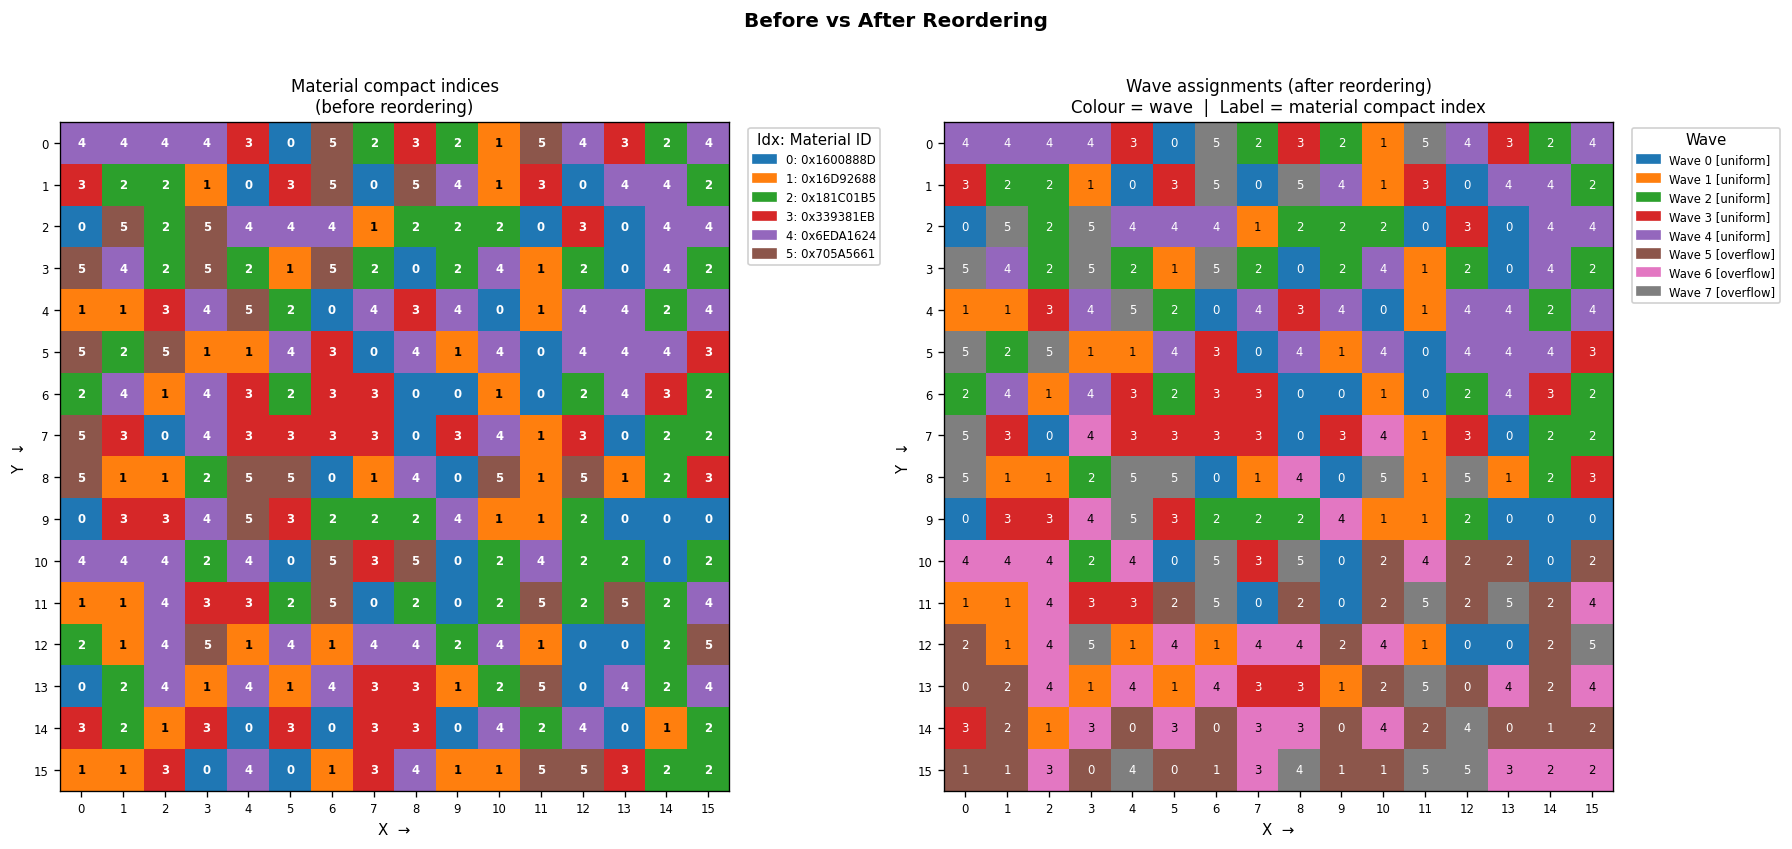

In [31]:
cmap_m = mat_cmap(num_unique)
cmap_w = wave_cmap()

wave_assign = np.empty((TILE_H, TILE_W), dtype=np.int32)
for w in range(NUM_WAVES):
    start = w * WAVE_SIZE
    for k in range(WAVE_SIZE):
        x, y = reordered_coords[start + k]
        wave_assign[y, x] = w

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Left: material compact indices ────────────────────────────────────────────
ax = axes[0]
ax.imshow(compact, cmap=cmap_m, vmin=-0.5, vmax=num_unique-0.5,
          interpolation='nearest', aspect='equal')
annotate_compact(ax, compact, cmap_m, num_unique)
ax.set_title('Material compact indices\n(before reordering)', fontsize=10)
ax.set_xlabel('X  →'); ax.set_ylabel('Y  ↓')
ax.set_xticks(range(TILE_W)); ax.set_yticks(range(TILE_H))
ax.set_xticklabels(range(TILE_W), fontsize=7)
ax.set_yticklabels(range(TILE_H), fontsize=7)
mat_legend(ax, num_unique, cmap_m, unique_ids)

# ── Right: wave assignments ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.imshow(wave_assign, cmap=cmap_w, vmin=-0.5, vmax=NUM_WAVES-0.5,
           interpolation='nearest', aspect='equal')
for row in range(TILE_H):
    for col in range(TILE_W):
        w  = wave_assign[row, col]
        tc = text_colour(cmap_w(w / max(NUM_WAVES-1, 1)))
        ax2.text(col, row, str(compact[row, col]),
                 ha='center', va='center', fontsize=7, color=tc)

ax2.set_title('Wave assignments (after reordering)\n'
              'Colour = wave  |  Label = material compact index', fontsize=10)
ax2.set_xlabel('X  →'); ax2.set_ylabel('Y  ↓')
ax2.set_xticks(range(TILE_W)); ax2.set_yticks(range(TILE_H))
ax2.set_xticklabels(range(TILE_W), fontsize=7)
ax2.set_yticklabels(range(TILE_H), fontsize=7)

# Highlight guaranteed-uniform vs overflow waves in legend
wave_patches = []
for w in range(NUM_WAVES):
    tag = '[uniform]' if w < uniform_waves else '[overflow]'
    wave_patches.append(
        mpatches.Patch(color=cmap_w(w / max(NUM_WAVES-1,1)), label=f'Wave {w} {tag}')
    )
ax2.legend(handles=wave_patches, loc='upper left', bbox_to_anchor=(1.02, 1.0),
           title='Wave', fontsize=7, framealpha=0.9)

plt.suptitle('Before vs After Reordering', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 8 — Quality Analysis

Compares three orderings:
- **Naïve sort** — consecutive assignment after sorting (old approach).
- **Packed** — this kernel's output.
- **Theoretical max** — upper bound on achievable uniform waves.


 Wave        Naïve sort         Packed (this kernel) 
       unique  /  uniformity   unique  /  uniformity 
────────────────────────────────────────────────────────
   0     1 / 100.0%           1 / 100.0%  = ✓ GUARANTEED
   1     2 /  75.0%           1 / 100.0%  ↑ ✓ GUARANTEED
   2     2 /  56.2%           1 / 100.0%  ↑ ✓ GUARANTEED
   3     1 / 100.0%           1 / 100.0%  = ✓ GUARANTEED
   4     2 /  93.8%           1 / 100.0%  ↑ ✓ GUARANTEED
   5     2 /  71.9%           3 /  56.2%  ↓ 
   6     1 / 100.0%           3 /  71.9%  ↓ 
   7     2 /  90.6%           2 /  90.6%  = 
────────────────────────────────────────────────────────
  Avg uniformity    : 85.9%  →  89.8%
  Fully uniform     : 3/8  →  5/8
  Theory max        : 5/8  ← ACHIEVED ✓


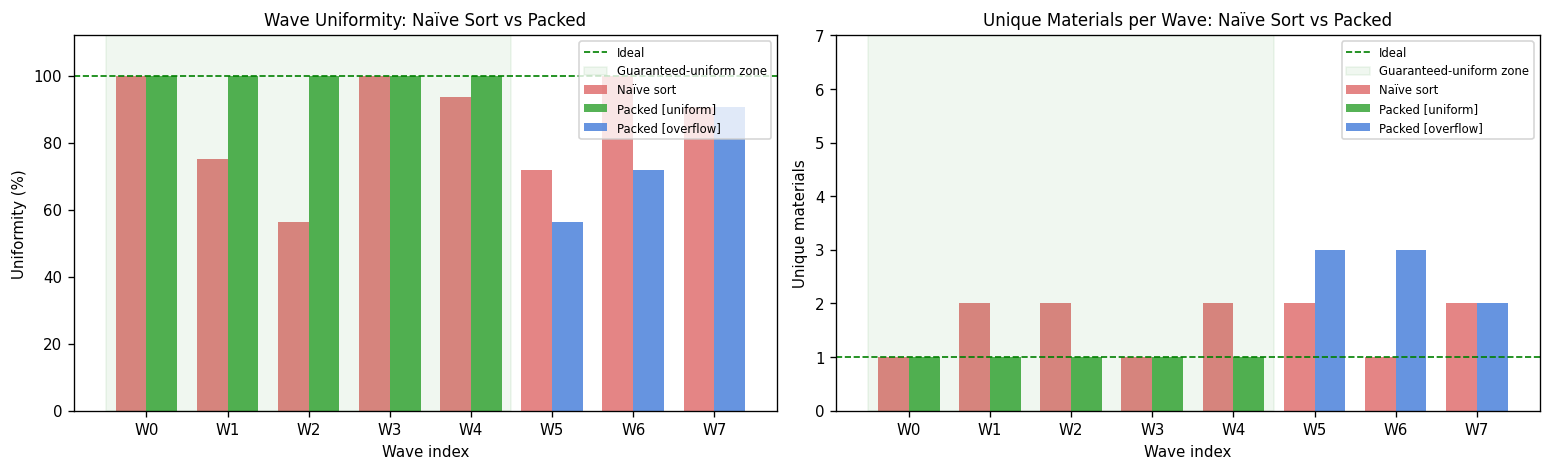

In [32]:
def wave_stats(coords, tile, id_to_compact, n_mats):
    stats = []
    for w in range(NUM_WAVES):
        start = w * WAVE_SIZE
        c_idxs = np.array([
            id_to_compact[tile[coords[start+k,1], coords[start+k,0]]]
            for k in range(WAVE_SIZE)
        ], dtype=np.int32)
        bc = np.bincount(c_idxs, minlength=n_mats)
        stats.append(dict(
            wave       = w,
            unique     = int(np.sum(bc > 0)),
            uniformity = float(bc.max()) / WAVE_SIZE,
            full       = (int(np.sum(bc > 0)) == 1),
        ))
    return stats


# Naïve sort baseline: sorted coordinates assigned consecutively
perm_naive        = np.argsort(tile_flat, kind='stable')
naive_coords      = np.stack([perm_naive % TILE_W, perm_naive // TILE_W], axis=1).astype(np.uint32)
stats_naive       = wave_stats(naive_coords,      tile, id_to_compact, num_unique)
stats_packed      = wave_stats(reordered_coords,  tile, id_to_compact, num_unique)

full_naive  = sum(1 for s in stats_naive  if s['full'])
full_packed = sum(1 for s in stats_packed if s['full'])

print(f"{'Wave':>5}  {'Naïve sort':^22}  {'Packed (this kernel)':^22}")
print(f"{'':>5}  {'unique  /  uniformity':^22}  {'unique  /  uniformity':^22}")
print('─' * 56)
for sn, sp in zip(stats_naive, stats_packed):
    tag = '✓ GUARANTEED' if sn['wave'] < uniform_waves else (
          '✓ (overflow)' if sp['full'] else '')
    # Compare packed vs naive
    better = '↑' if sp['uniformity'] > sn['uniformity'] else (
             '=' if sp['uniformity'] == sn['uniformity'] else '↓')
    print(
        f"  {sn['wave']:>2}    {sn['unique']:>2} / {sn['uniformity']*100:5.1f}%"
        f"          {sp['unique']:>2} / {sp['uniformity']*100:5.1f}%  {better} {tag}"
    )
print('─' * 56)
avg_n = np.mean([s['uniformity'] for s in stats_naive])  * 100
avg_p = np.mean([s['uniformity'] for s in stats_packed]) * 100
print(f"  Avg uniformity    : {avg_n:.1f}%  →  {avg_p:.1f}%")
print(f"  Fully uniform     : {full_naive}/{NUM_WAVES}  →  {full_packed}/{NUM_WAVES}")
print(f"  Theory max        : {max_full_waves}/{NUM_WAVES}  "
      f"← {'ACHIEVED ✓' if full_packed >= max_full_waves else 'not achieved'}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x, bw = np.arange(NUM_WAVES), 0.38

unif_n = [s['uniformity']*100 for s in stats_naive]
unif_p = [s['uniformity']*100 for s in stats_packed]
uniq_n = [s['unique']          for s in stats_naive]
uniq_p = [s['unique']          for s in stats_packed]

# Colour packed bars: green for guaranteed-uniform waves, blue otherwise
packed_colors = ['#44aa44' if w < uniform_waves else '#5588dd' for w in range(NUM_WAVES)]

for ax, vals_n, vals_p, ylabel, title, ideal, ylim in [
    (axes[0], unif_n, unif_p, 'Uniformity (%)',
     'Wave Uniformity: Naïve Sort vs Packed', 100, (0, 112)),
    (axes[1], uniq_n, uniq_p, 'Unique materials',
     'Unique Materials per Wave: Naïve Sort vs Packed', 1, (0, num_unique+1)),
]:
    ax.bar(x - bw/2, vals_n, bw, label='Naïve sort', color='#e07070', alpha=0.85)
    for i, (xi, v) in enumerate(zip(x, vals_p)):
        ax.bar(xi + bw/2, v, bw, color=packed_colors[i],
               alpha=0.9, label=('Packed [uniform]' if i == 0 else
                                  'Packed [overflow]' if i == uniform_waves else '_'))
    ax.axhline(ideal, color='green', linestyle='--', linewidth=1, label='Ideal')
    if uniform_waves > 0:
        ax.axvspan(-0.5, uniform_waves - 0.5, alpha=0.06, color='green',
                   label='Guaranteed-uniform zone')
    ax.set_xlabel('Wave index'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticks(x); ax.set_xticklabels([f'W{i}' for i in range(NUM_WAVES)])
    ax.set_ylim(*ylim)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=7)

plt.tight_layout()
plt.show()


---
## 9 — Timing Benchmark

The kernel is timed over `N_BENCHMARK` iterations with GPU synchronisation.

Benchmarking  (200 runs) …

  CPU (NumPy)       mean=  68.50 µs  median=  58.10 µs  min= 53.50 µs  p5–p95=[54.20, 120.01] µs
  GPU timing skipped.


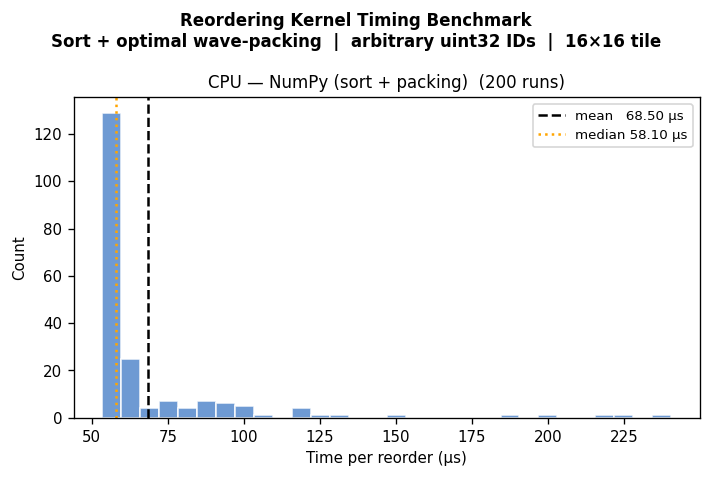

In [33]:
def benchmark_cpu(tile_flat, n_runs=N_BENCHMARK):
    times = np.empty(n_runs)
    for i in range(n_runs):
        t0 = time.perf_counter()
        cpu_reorder(tile_flat)
        times[i] = (time.perf_counter() - t0) * 1e6
    return times


def benchmark_gpu(tile_flat, module, n_runs=N_BENCHMARK, n_warmup=20):
    sync = None
    try:
        import torch
        if torch.cuda.is_available(): sync = torch.cuda.synchronize
    except ImportError:
        pass
    if sync is None and hasattr(module, 'device') and hasattr(module.device, 'sync'):
        sync = module.device.sync
    if sync is None:
        sync = lambda: None
        print("  Note: no GPU sync found — times include Python/driver overhead.")

    for _ in range(n_warmup):
        gpu_reorder(tile_flat, module)
    sync()

    times = np.empty(n_runs)
    for i in range(n_runs):
        sync()
        t0 = time.perf_counter()
        gpu_reorder(tile_flat, module)
        sync()
        times[i] = (time.perf_counter() - t0) * 1e6
    return times


def print_stats(label, times):
    p5, p95 = np.percentile(times, [5, 95])
    print(f"  {label:<16}  mean={times.mean():7.2f} µs  "
          f"median={np.median(times):7.2f} µs  "
          f"min={times.min():6.2f} µs  "
          f"p5–p95=[{p5:.2f}, {p95:.2f}] µs")


print(f"Benchmarking  ({N_BENCHMARK} runs) …\n")
times_cpu = benchmark_cpu(tile_flat)
print_stats('CPU (NumPy)', times_cpu)

times_gpu = None
if USING_GPU:
    times_gpu = benchmark_gpu(tile_flat, slang_module)
    print_stats('GPU (Slang)', times_gpu)
    print(f"\n  GPU speedup (mean): {times_cpu.mean() / times_gpu.mean():.2f}×")
else:
    print("  GPU timing skipped.")

n_p = 2 if times_gpu is not None else 1
fig, axes = plt.subplots(1, n_p, figsize=(6*n_p, 4))
if n_p == 1: axes = [axes]

def _panel(ax, times, label, color):
    ax.hist(times, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(times.mean(),     color='black',  ls='--', lw=1.5,
               label=f'mean   {times.mean():.2f} µs')
    ax.axvline(np.median(times), color='orange', ls=':',  lw=1.5,
               label=f'median {np.median(times):.2f} µs')
    ax.set_xlabel('Time per reorder (µs)'); ax.set_ylabel('Count')
    ax.set_title(f'{label}  ({len(times)} runs)'); ax.legend(fontsize=8)

_panel(axes[0], times_cpu, 'CPU — NumPy (sort + packing)', '#5588cc')
if times_gpu is not None:
    _panel(axes[1], times_gpu, 'GPU — Slang bitonic sort + packing', '#44aa66')

fig.suptitle('Reordering Kernel Timing Benchmark\n'
             'Sort + optimal wave-packing  |  arbitrary uint32 IDs  |  16×16 tile',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 10 — Summary Figure

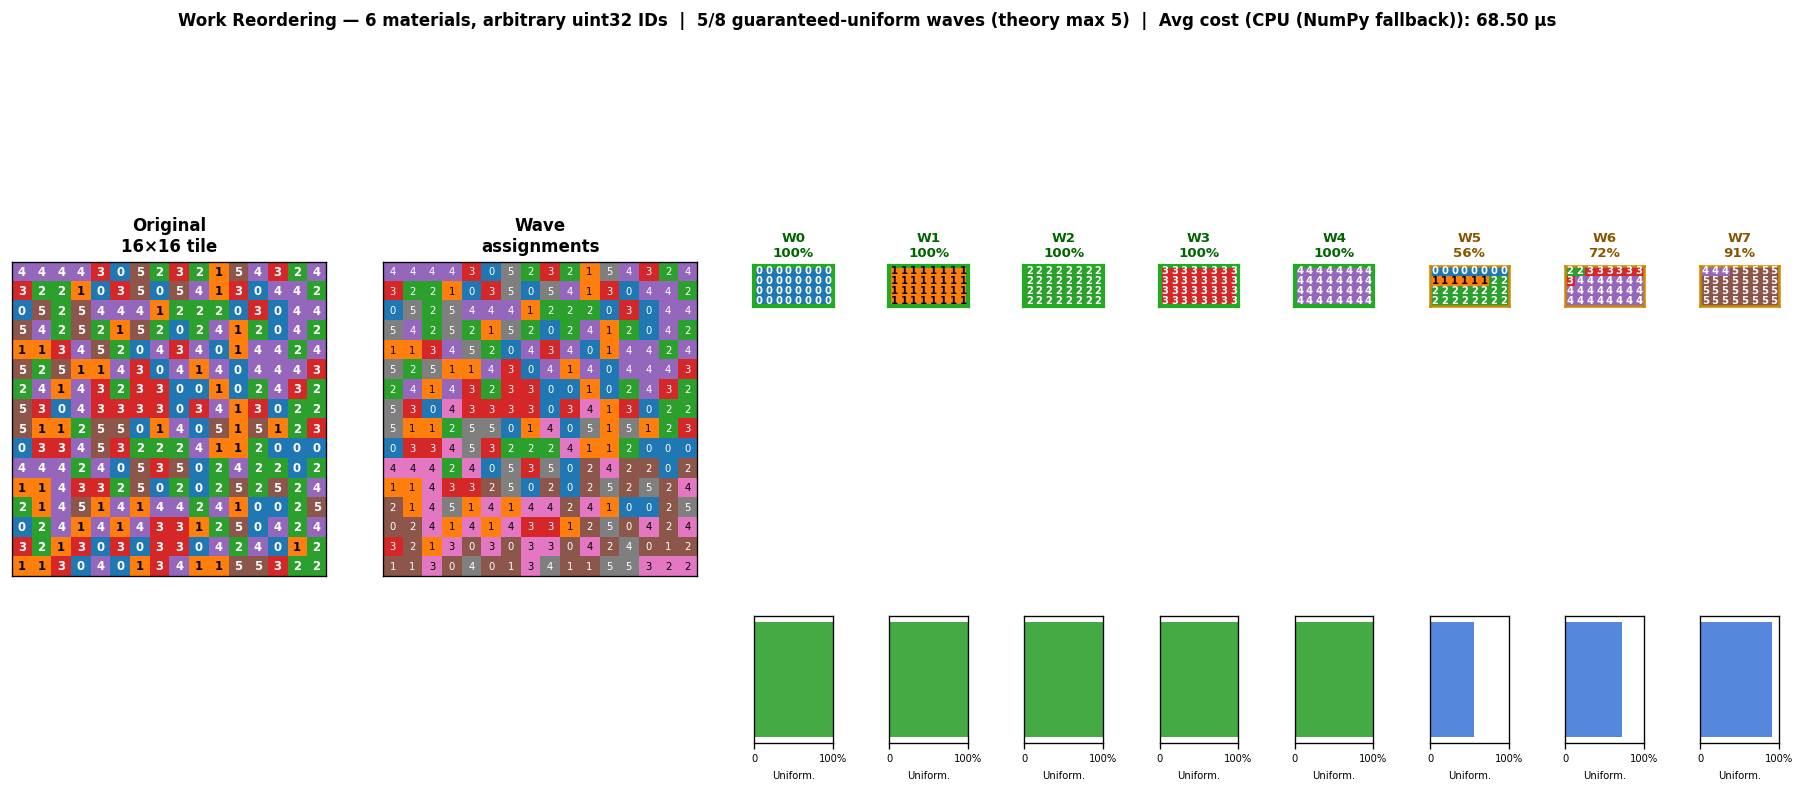

In [34]:
fig = plt.figure(figsize=(19, 7))
gs  = GridSpec(2, NUM_WAVES + 2, figure=fig,
               hspace=0.55, wspace=0.45,
               width_ratios=[4, 4] + [1]*NUM_WAVES,
               height_ratios=[3, 1])

# ── Original tile ─────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[:, 0])
ax0.imshow(compact, cmap=cmap_m, vmin=-0.5, vmax=num_unique-0.5,
           interpolation='nearest', aspect='equal')
annotate_compact(ax0, compact, cmap_m, num_unique)
ax0.set_title('Original\n16×16 tile', fontweight='bold')
ax0.set_xticks([]); ax0.set_yticks([])

# ── Wave assignment ───────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[:, 1])
ax1.imshow(wave_assign, cmap=cmap_w, vmin=-0.5, vmax=NUM_WAVES-0.5,
           interpolation='nearest', aspect='equal')
for row in range(TILE_H):
    for col in range(TILE_W):
        w  = wave_assign[row, col]
        tc = text_colour(cmap_w(w / max(NUM_WAVES-1, 1)))
        ax1.text(col, row, str(compact[row, col]),
                 ha='center', va='center', fontsize=6, color=tc)
ax1.set_title('Wave\nassignments', fontweight='bold')
ax1.set_xticks([]); ax1.set_yticks([])

# ── Individual wave panels + uniformity bars ──────────────────────────────────
for w in range(NUM_WAVES):
    wgrid   = compact_wave_grid(reordered_coords, tile, id_to_compact, w)
    flat_w  = wgrid.flatten()
    bc      = np.bincount(flat_w, minlength=num_unique)
    unif    = int(bc.max()) / WAVE_SIZE * 100
    n_uniq  = int(np.sum(bc > 0))
    is_guar = (w < uniform_waves)

    ax_w = fig.add_subplot(gs[0, w + 2])
    ax_w.imshow(wgrid, cmap=cmap_m, vmin=-0.5, vmax=num_unique-0.5,
                interpolation='nearest', aspect='equal')
    annotate_compact(ax_w, wgrid, cmap_m, num_unique, fs=6)
    ax_w.set_title(f'W{w}\n{unif:.0f}%',
                   fontsize=8,
                   color='darkgreen' if is_guar else '#885500',
                   fontweight='bold')
    ax_w.set_xticks([]); ax_w.set_yticks([])
    for spine in ax_w.spines.values():
        spine.set_linewidth(2.5 if is_guar else 1.5)
        spine.set_edgecolor('#22aa22' if is_guar else '#cc8800')

    ax_b = fig.add_subplot(gs[1, w + 2])
    bar_color = '#44aa44' if is_guar else ('#5588dd' if unif >= 50 else '#dd5555')
    ax_b.barh([0], [unif], color=bar_color, height=0.5)
    ax_b.set_xlim(0, 100)
    ax_b.set_xticks([0, 100]); ax_b.set_xticklabels(['0','100%'], fontsize=6)
    ax_b.set_yticks([]); ax_b.set_xlabel('Uniform.', fontsize=6)

label  = 'GPU (SlangPy)' if USING_GPU else 'CPU (NumPy fallback)'
t_mean = (times_gpu.mean() if USING_GPU and times_gpu is not None else times_cpu.mean())
fig.suptitle(
    f'Work Reordering — {num_unique} materials, arbitrary uint32 IDs  |  '
    f'{uniform_waves}/{NUM_WAVES} guaranteed-uniform waves '
    f'(theory max {max_full_waves})  |  '
    f'Avg cost ({label}): {t_mean:.2f} µs',
    fontsize=10, fontweight='bold'
)
plt.show()
